In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib


In [3]:
df = pd.read_csv("LengthOfStay.csv")
print("Shape:", df.shape)
df.head()



Shape: (100000, 28)


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  object 
 2   rcount                      100000 non-null  object 
 3   gender                      100000 non-null  object 
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000 non-null  int64  
 13  malnutrition   

In [5]:
df.isnull().sum()

,0
eid,0
vdate,0
rcount,0
gender,0
dialysisrenalendstage,0
asthma,0
irondef,0
pneum,0
substancedependence,0
psychologicaldisordermajor,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,eid,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,...,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,50000.500000,0.036420,0.035270,0.094940,0.039450,0.063060,0.239040,0.051660,0.049390,0.004790,...,10.177455,137.891397,141.963384,14.097185,1.099350,29.805759,73.444720,6.493768,2.123310,4.00103
std,28867.657797,0.187334,0.184462,0.293134,0.194664,0.243072,0.426499,0.221341,0.216682,0.069044,...,5.353131,2.999669,29.992996,12.952454,0.200262,2.003769,11.644555,0.568473,2.050641,2.36031
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.100000,124.912632,-1.005927,1.000000,0.219770,21.992683,21.000000,0.200000,0.000000,1.00000
25%,25000.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,135.871062,121.682383,11.000000,0.964720,28.454235,66.000000,6.500000,1.000000,2.00000
50%,50000.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,9.400000,137.887151,142.088545,12.000000,1.098764,29.807516,73.000000,6.500000,1.000000,4.00000
75%,75000.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,11.500000,139.912885,162.180996,14.000000,1.234867,31.156885,81.000000,6.500000,3.000000,6.00000
max,100000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,245.900000,151.387283,271.444277,682.500000,2.035202,38.935293,130.000000,10.000000,10.000000,17.00000


In [8]:
df.select_dtypes(include="object").nunique()

,0
vdate,367
rcount,6
gender,2
discharged,378
facid,5


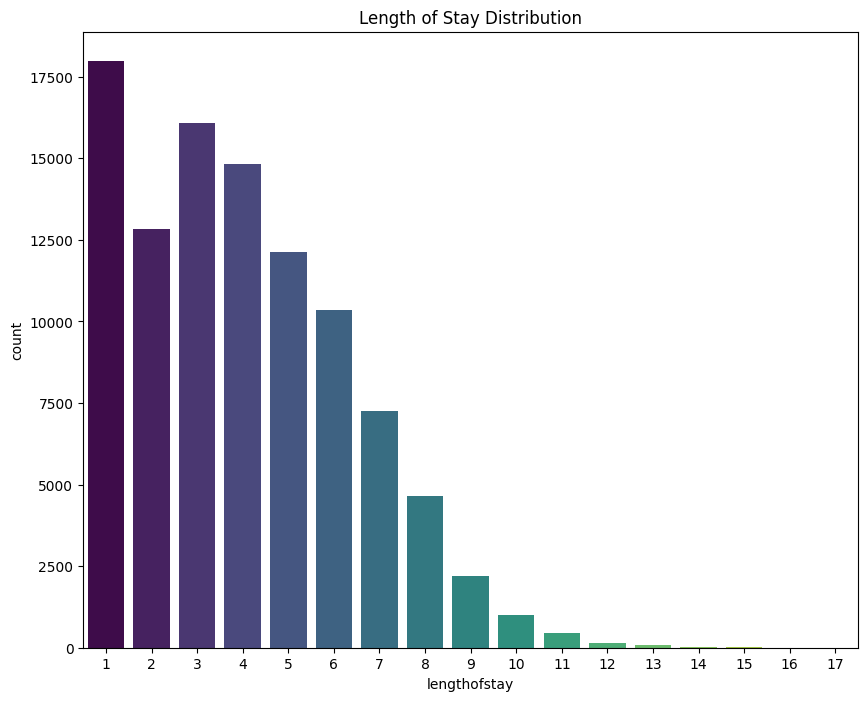

In [9]:
plt.figure(figsize=(10,8))
sns.countplot(data=df,
              x="lengthofstay",
              hue="lengthofstay",
              palette="viridis",
              legend=False)

plt.title("Length of Stay Distribution")
plt.show()

In [10]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

print(numeric_cols)

Index(['eid', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum',
       'substancedependence', 'psychologicaldisordermajor', 'depress',
       'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit',
       'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine',
       'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9',
       'lengthofstay'],
      dtype='object')


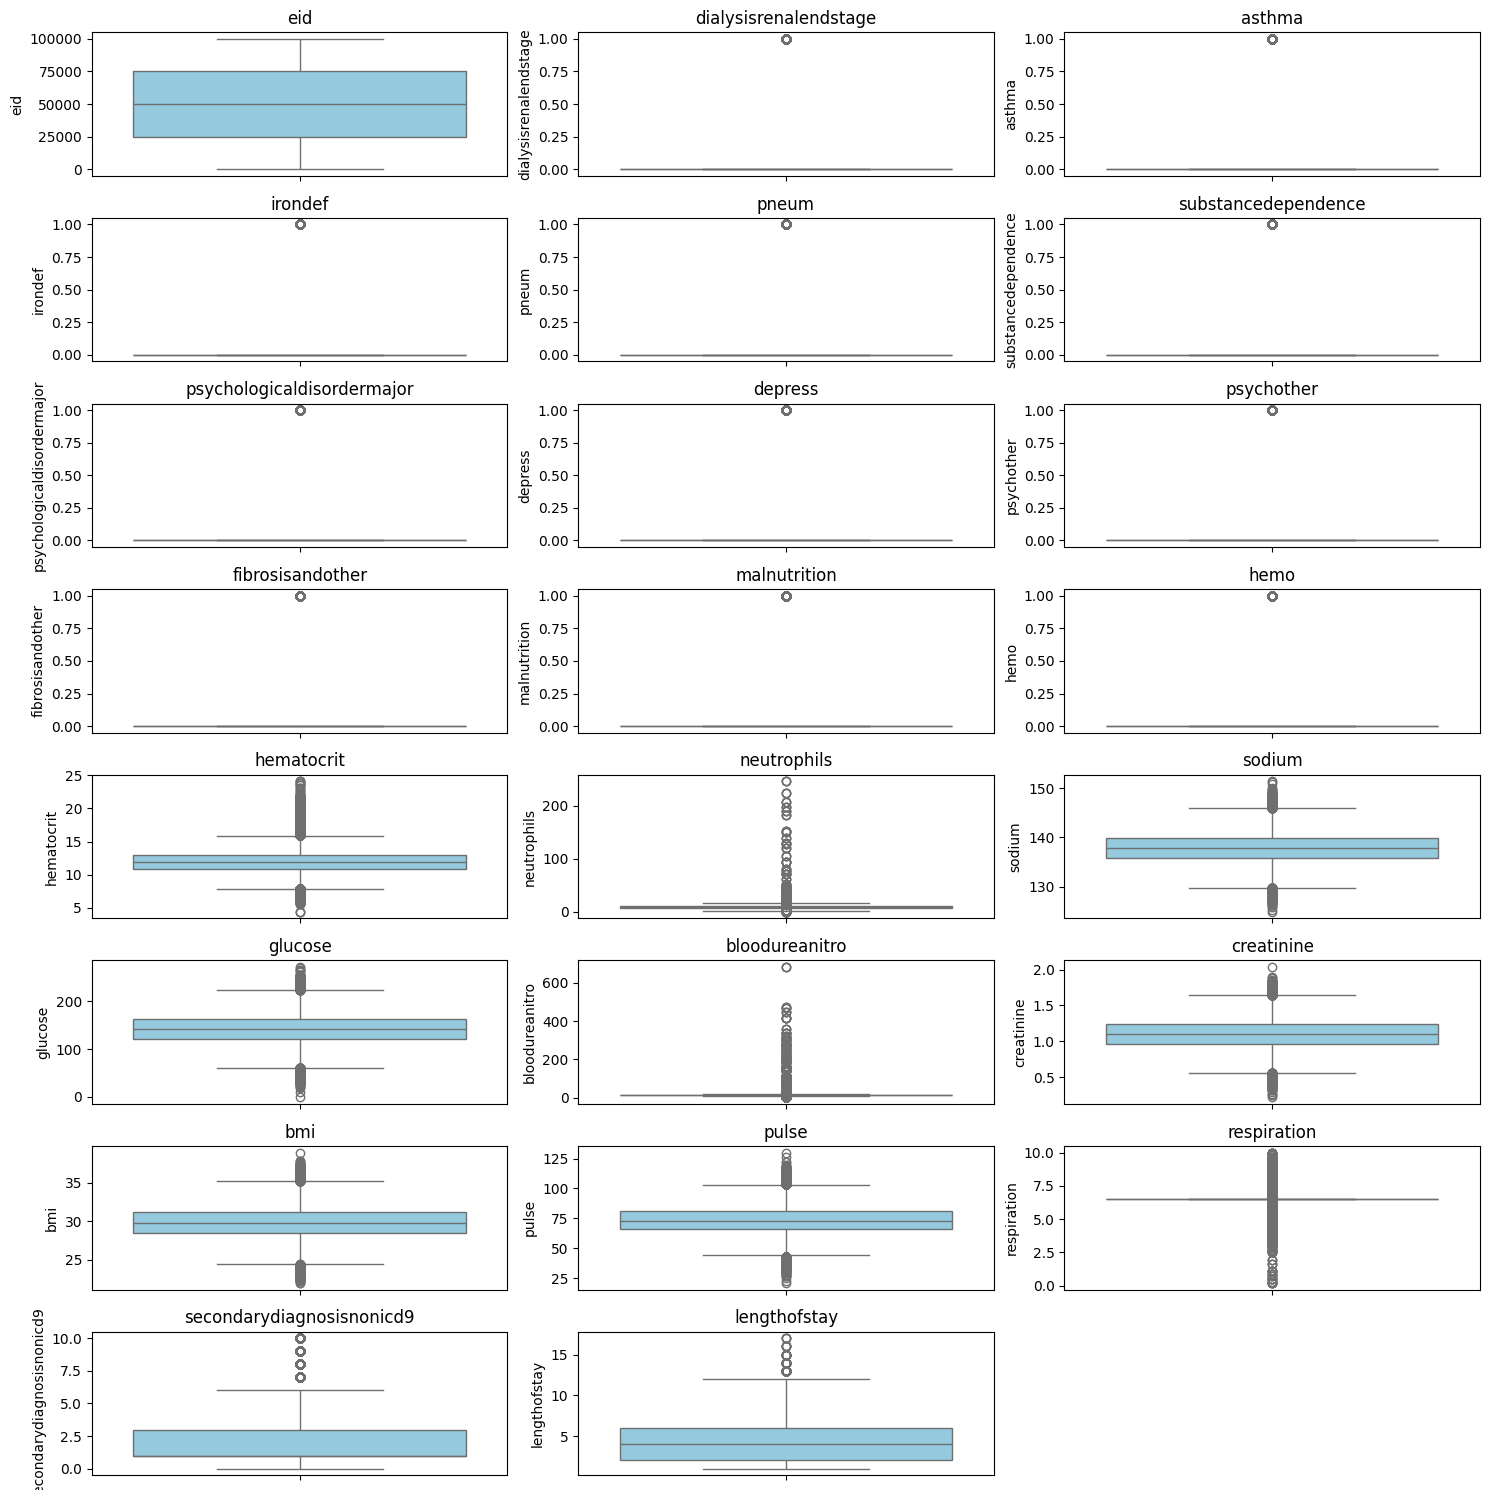

In [11]:
plt.figure(figsize=(15,15))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot((len(numeric_cols)+2)//3, 3, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [12]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)}")

eid: 0
dialysisrenalendstage: 3642
asthma: 3527
irondef: 9494
pneum: 3945
substancedependence: 6306
psychologicaldisordermajor: 23904
depress: 5166
psychother: 4939
fibrosisandother: 479
malnutrition: 4948
hemo: 8000
hematocrit: 5616
neutrophils: 6515
sodium: 711
glucose: 695
bloodureanitro: 19592
creatinine: 675
bmi: 685
pulse: 1054
respiration: 35167
secondarydiagnosisnonicd9: 5016
lengthofstay: 132


In [13]:
continuous_cols = [
    "hematocrit",
    "neutrophils",
    "sodium",
    "glucose",
    "bloodureanitro",
    "creatinine",
    "bmi",
    "pulse",
    "respiration"
]

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

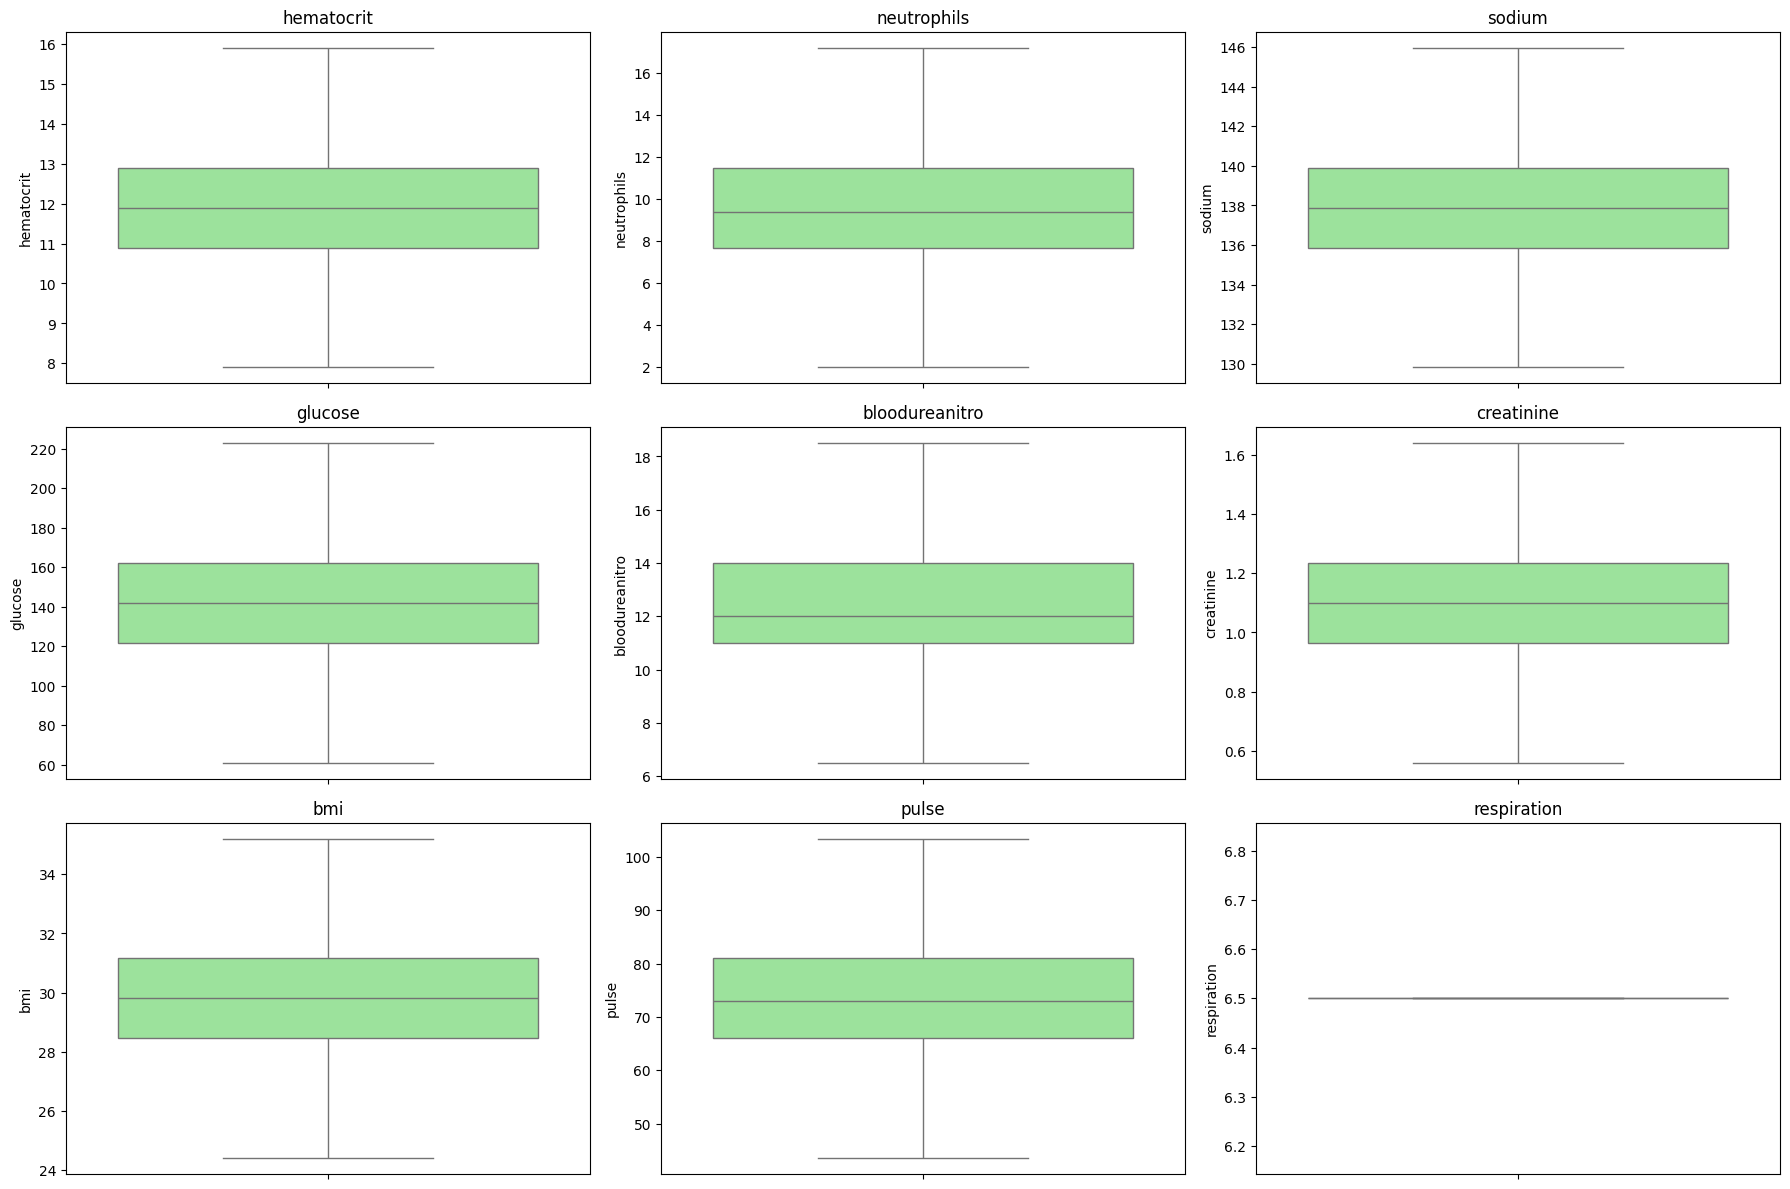

In [14]:
plt.figure(figsize=(18,12))

for i, col in enumerate(continuous_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col], color="lightgreen")
    plt.title(col)

plt.tight_layout()
plt.show()

In [15]:
df["rcount"] = df["rcount"].replace("5+", "5")
df["rcount"] = pd.to_numeric(df["rcount"], errors="coerce")

In [16]:
df = pd.get_dummies(
    df,
    columns=["gender", "facid"],
    drop_first=True,
    dtype=int
)

In [17]:
df["vdate"] = pd.to_datetime(df["vdate"])

In [18]:
df["year"] = df["vdate"].dt.year
df["month"] = df["vdate"].dt.month
df["day"] = df["vdate"].dt.day
df["dayofweek"] = df["vdate"].dt.dayofweek
df["quarter"] = df["vdate"].dt.quarter

In [19]:
df["long_stay"] = (df["lengthofstay"] > 3).astype(int)

In [20]:
disease_cols = [
    'dialysisrenalendstage',
    'asthma',
    'irondef',
    'pneum',
    'substancedependence',
    'psychologicaldisordermajor',
    'depress',
    'psychother',
    'fibrosisandother',
    'malnutrition',
    'hemo'
]

df["disease_count"] = df[disease_cols].sum(axis=1)

In [21]:
df["high_risk"] = (df["disease_count"] >= 3).astype(int)

In [22]:

df["abnormal_lab_score"] = (
    (df["glucose"] > 140).astype(int) +
    (df["creatinine"] > 1.3).astype(int) +
    (df["bloodureanitro"] > 20).astype(int)
)


In [23]:

df["high_pulse"] = (df["pulse"] > 100).astype(int)

In [24]:

df["high_respiration"] = (df["respiration"] > 20).astype(int)

In [25]:

df["long_stay"] = (df["lengthofstay"] > 3).astype(int)

In [26]:
exclude_cols = [
    "eid",
    "vdate",
    "discharged",
    "lengthofstay",
    "long_stay"
]

X = df.drop(columns=exclude_cols)
y = df["long_stay"]

In [27]:
print(y.value_counts())

print(y.value_counts(normalize=True))

long_stay
1    53128
0    46872
Name: count, dtype: int64
long_stay
1    0.53128
0    0.46872
Name: proportion, dtype: float64


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        )

}

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():


    if name in ["Decision Tree", "Random Forest"]:

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    else:

        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)


results_df = results_df.sort_values(
    by=["F1 Score", "Accuracy"],
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.93796,0.951574,0.930583,0.940962
1,Decision Tree,0.87764,0.972456,0.792125,0.873076
0,Logistic Regression,0.86392,0.905051,0.831050,0.866473
3,KNN,0.82968,0.891395,0.773679,0.828376


In [32]:
results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.9380,0.9516,0.9306,0.9410
1,Decision Tree,0.8776,0.9725,0.7921,0.8731
0,Logistic Regression,0.8639,0.9051,0.8310,0.8665
3,KNN,0.8297,0.8914,0.7737,0.8284


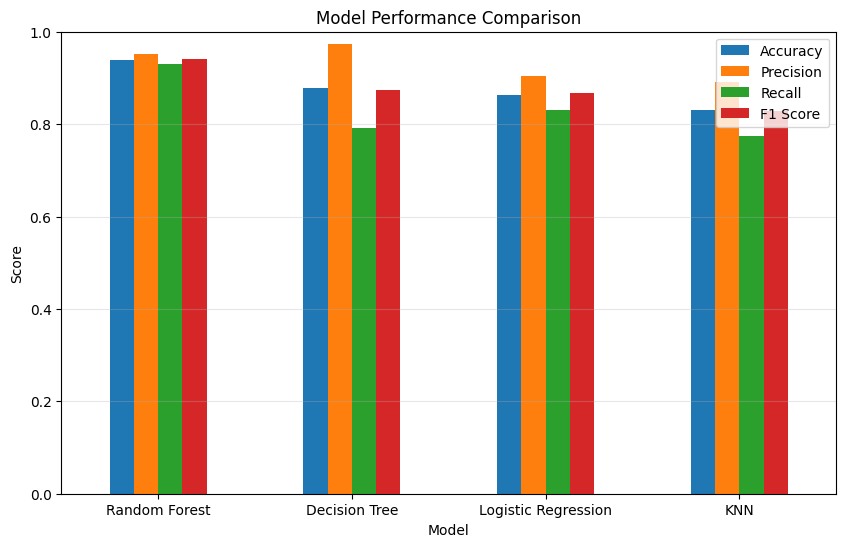

In [33]:
metrics = results_df.set_index("Model")

metrics.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.grid(axis="y", alpha=0.3)

plt.show()

In [34]:
best_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)

In [35]:

y_pred = best_rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93     11718
           1       0.95      0.93      0.94     13282

    accuracy                           0.94     25000
   macro avg       0.94      0.94      0.94     25000
weighted avg       0.94      0.94      0.94     25000



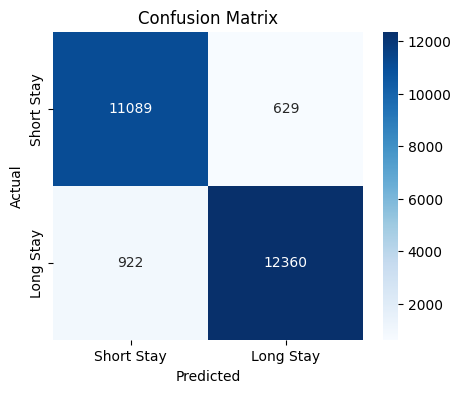

In [36]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Short Stay", "Long Stay"],
    yticklabels=["Short Stay", "Long Stay"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [37]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance.head(10))

          Feature  Importance
0          rcount    0.465527
32  disease_count    0.095645
12     hematocrit    0.042970
18            bmi    0.037278
15        glucose    0.036720
17     creatinine    0.036113
14         sodium    0.035890
19          pulse    0.032127
26        facid_E    0.029999
13    neutrophils    0.026726


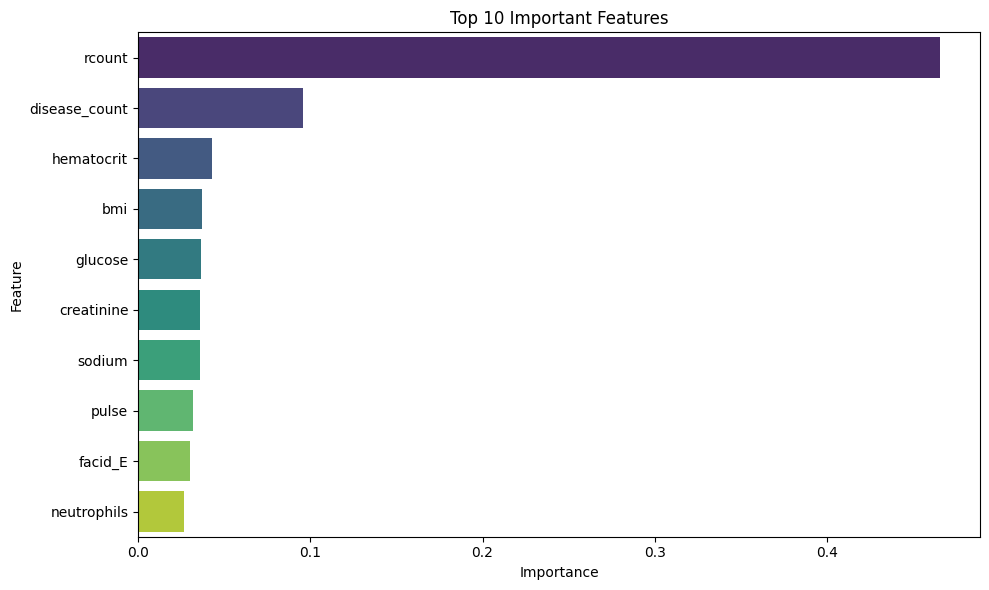

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)


plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

In [39]:

joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [40]:

joblib.dump(best_rf, "best_rf_model.pkl", compress=9)

['best_rf_model.pkl']